# Methodological Note on Logistic Regression

Logistic regression is a statistical method used to model the probability of a binary outcome as a function of one or more explanatory variables. It belongs to the class of generalized linear models and is particularly suited for cases where the dependent variable $Y$ is dichotomous, taking values in $\{0,1\}$.

## Model Specification

The logistic regression model expresses the log-odds of the probability of success as a linear combination of predictors. For a vector of covariates $X = (X_{1}, X_{2}, \ldots, X_{p})$, the model is:

$$
\text{logit}(P(Y=1 \mid X)) = \log\left(\frac{P(Y=1 \mid X)}{1 - P(Y=1 \mid X)}\right) = \beta_{0} + \beta_{1}X_{1} + \cdots + \beta_{p}X_{p}.
$$

Equivalently, the conditional probability can be written as:

$$
P(Y=1 \mid X) = \frac{1}{1 + \exp[-(\beta_{0} + \beta_{1}X_{1} + \cdots + \beta_{p}X_{p})]}.
$$

## Likelihood and Estimation

The logistic regression coefficients are typically estimated by maximum likelihood. For independent observations $(y_{i}, X_{i})$ with $i = 1,\ldots,n$, the likelihood function is:

$$
L(\beta) = \prod_{i=1}^{n} P(Y_{i}=y_{i} \mid X_{i}).
$$

With the logistic model, this becomes:

$$
L(\beta) = \prod_{i=1}^{n} \left[\pi_{i}\right]^{y_{i}} \left[1-\pi_{i}\right]^{1-y_{i}},
$$

where $\pi_{i} = P(Y_{i}=1 \mid X_{i})$. The log-likelihood is:

$$
\ell(\beta) = \sum_{i=1}^{n} \left[ y_{i} \log(\pi_{i}) + (1-y_{i}) \log(1-\pi_{i}) \right].
$$

Maximization of $\ell(\beta)$ is achieved through numerical methods such as Newton-Raphson or iteratively reweighted least squares (IRLS).

## Interpretation of Coefficients

Each coefficient $\beta_{j}$ represents the change in the log-odds of the outcome associated with a one-unit increase in $X_{j}$, holding other covariates fixed. In odds ratio terms:

$$
\exp(\beta_{j}) = \frac{\text{odds}(Y=1 \mid X_{j}+1)}{\text{odds}(Y=1 \mid X_{j})}.
$$

Thus, $\exp(\beta_{j})$ is the multiplicative effect on the odds for a one-unit increment in $X_{j}$.

## Assumptions and Diagnostic Considerations

Key assumptions of logistic regression include:
- The dependent variable is binary.
- Observations are independent.
- The relationship between the log-odds and each predictor is linear.
- There is no perfect multicollinearity among predictors.
- Large-sample approximations justify inference based on the asymptotic distribution of estimators.

Diagnostics typically involve:
- Assessing model fit via likelihood-ratio tests, Wald tests, and information criteria.
- Examining residuals and influence measures.
- Checking for separation or quasi-separation, which can impair estimation.

## Summary

Logistic regression provides a principled framework for modeling binary outcomes with interpretable coefficients. Its foundation in maximum likelihood estimation and its explicit link between covariates and outcome probabilities make it a standard method in many applied fields, including epidemiology, social sciences, and machine learning.

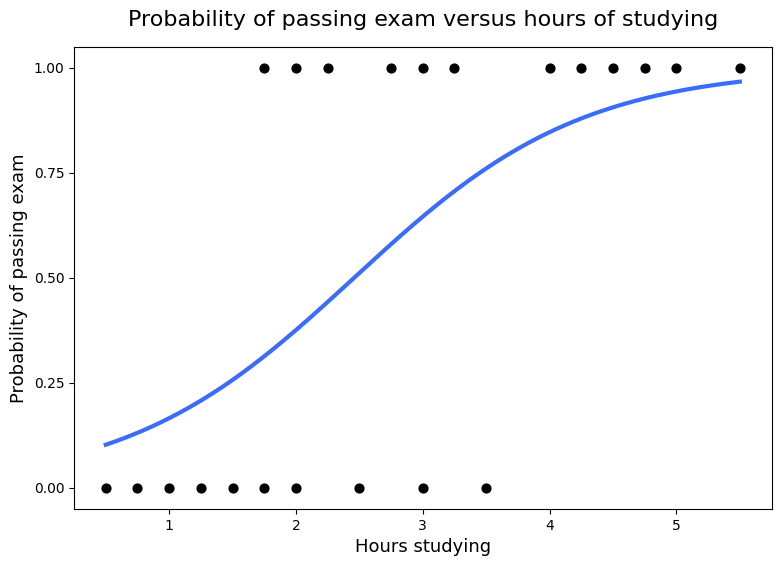

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# 1. Ricreiamo dei dati simili a quelli del grafico
# Ore di studio (X) e se l'esame è stato superato (y: 0=No, 1=Sì)
X = np.array([0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 1.75, 2.0, 2.0, 2.25, 2.5, 2.75, 3.0, 3.0, 3.25, 3.5, 4.0, 4.25, 4.5, 4.75, 5.0, 5.5]).reshape(-1, 1)
y = np.array([0,   0,    0,   0,    0,   0,    1,    0,   1,   1,    0,   1,    0,   1,   1,    0,   1,   1,    1,   1,    1,   1])

# 2. Addestriamo il modello di regressione logistica
model = LogisticRegression()
model.fit(X, y)

# 3. Creiamo un vettore di ore continuo (da 0.5 a 5.5) per disegnare la curva morbida
X_curve = np.linspace(0.5, 5.5, 300).reshape(-1, 1)

# Calcoliamo le probabilità per la curva (vogliamo la probabilità della classe 1)
y_proba = model.predict_proba(X_curve)[:, 1]

# 4. Grafico (Stile ggplot2-like)
plt.figure(figsize=(9, 6))
# Disegniamo la curva sigmoide blu
plt.plot(X_curve, y_proba, color="#3B6CFFFF", linewidth=3, label='Probabilità stimata')

# Disegniamo i punti neri dei dati reali (0 e 1)
plt.scatter(X, y, color='black', s=40, zorder=5)

# Formattazione degli assi e testi
plt.title('Probability of passing exam versus hours of studying', fontsize=16, pad=15)
plt.xlabel('Hours studying', fontsize=13)
plt.ylabel('Probability of passing exam', fontsize=13)

# Impostiamo i tick dell'asse Y come nel tuo grafico
plt.yticks([0.00, 0.25, 0.50, 0.75, 1.00])

# Rimuoviamo i bordi del grafico per renderlo identico a R/ggplot2
for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()

## 4. Evaluation and Validation of Logistic Regression Models

Having formalized the framework of Logistic Regression and the estimation of its parameters via Maximum Likelihood Estimation (MLE), we must establish a rigorous methodology to assess the model’s goodness-of-fit, predictive power, and generalization capabilities. 

Unlike linear regression—where the coefficient of determination $R^2$ and residual analysis provide a straightforward evaluation—the binary nature of the dependent variable $y \in \{0, 1\}$ necessitates alternative evaluation paradigms. These are broadly categorized into **probabilistic framework assessments** and **classification discriminative metrics**.

### 4.1 Diagnostic Framework for Continuous Probabilities

Before converting the continuous output of the sigmoidal function $\hat{y} = \sigma(w^T x + b)$ into hard binary decisions, we evaluate the calibration and quality of the predicted probabilities themselves.

#### 4.1.1 Logarithmic Loss (Cross-Entropy)
The fundamental metric for assessing predicted probabilities is the **Logarithmic Loss** (or Log Loss), which directly mirrors the negative log-likelihood function minimized during training. For a test dataset of $m$ observations, it is defined as:

$$J(w, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

Where:
* $y^{(i)}$ is the true binary label.
* $\hat{y}^{(i)} \in (0, 1)$ is the probability predicted by the model.

**Methodological Interpretation:** Log Loss heavily penalizes confident but incorrect predictions. If the model assigns a probability $\hat{y} \to 1$ to an instance whose true label is $y = 0$, the loss asymptotically approaches infinity ($-\log(0) \to \infty$). A lower Log Loss signifies superior probabilistic calibration.

#### 4.1.2 McFadden's Pseudo-$R^2$
In logistic regression, an exact parallel to the linear $R^2$ does not exist. Instead, measures of "Pseudo-$R^2$" are utilized. McFadden's formulation compares the log-likelihood of the full fitted model ($L_{fit}$) against an intercept-only null model ($L_{null}$):

$$R^2_{\text{McFadden}} = 1 - \frac{\ln(L_{fit})}{\ln(L_{null})}$$

A value between $0.2$ and $0.4$ represents an excellent model fit, corresponding to highly significant explanatory power.

### 4.2 Classification Framework (Discriminative Metrics)

To employ the model as a classifier, continuous probabilities must be mapped onto a discrete decision space $\{0, 1\}$ via a decision threshold $\tau$ (conventionally $\tau = 0.5$):

$$Y_{pred} = \begin{cases} 1 & \text{if } \hat{y} \ge \tau \\ 0 & \text{if } \hat{y} < \tau \end{cases}$$

#### 4.2.1 The Confusion Matrix
The mapping of predicted classes against actual classes yields a $2 \times 2$ contingency table known as the **Confusion Matrix**:

| | Actual $y = 1$ | Actual $y = 0$ |
| :--- | :--- | :--- |
| **Predicted $Y_{pred} = 1$** | True Positive ($TP$) | False Positive ($FP$) |
| **Predicted $Y_{pred} = 0$** | False Negative ($FN$) | True Negative ($TN$) |

From this matrix, we derive four fundamental academic metrics:

* **Accuracy:** The overall proportion of correct predictions.
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
*Critique:* In the presence of highly imbalanced datasets, Accuracy suffers from the *accuracy paradox* and becomes an uninformative metric.

* **Precision (Positive Predictive Value):** The fidelity of the positive predictions.
$$\text{Precision} = \frac{TP}{TP + FP}$$

* **Recall (Sensitivity / True Positive Rate):** The capacity of the model to capture all true positive instances.
$$\text{Recall} = \frac{TP}{TP + FN}$$

* **F1-Score:** The harmonic mean of Precision and Recall, providing a robust balance in asymmetric class distributions.
$$\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

### 4.3 Threshold-Independent Validation

Evaluating a model solely at $\tau = 0.5$ introduces arbitrary bias. A comprehensive methodological assessment requires analyzing performance across *all* possible decision thresholds.

In [13]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss, roc_auc_score, confusion_matrix

# 1. DATASET SIMULATION (Hours studying vs Exam Passing)
# Generating a synthetic dataset based on the previous educational scenario
np.random.seed(42)
X = np.array([0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 1.75, 2.0, 2.0, 2.25, 2.5, 2.75, 3.0, 3.0, 3.25, 3.5, 4.0, 4.25, 4.5, 4.75, 5.0, 5.5]).reshape(-1, 1)
y = np.array([0,   0,    0,   0,    0,   0,    1,    0,   1,   1,    0,   1,    0,   1,   1,    0,   1,   1,    1,   1,    1,   1])

# 2. VALIDATION PROTOCOL: HOLDOUT METHOD (Train-Test Split)
# Partitioning the dataset into Training Set (80%) and Test Set (20%) to evaluate generalization error
# We use stratification to preserve the baseline class distribution across folds
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Storing baseline probability for the null (intercept-only) model calculation
y_null_prob = np.mean(y_train)

# 3. MODEL ESTIMATION (Maximum Likelihood Estimation)
# Initializing the estimator without regularization to align with standard academic MLE framework
model = LogisticRegression()
model.fit(X_train, y_train)

# 4. PREDICTIONS EVALUATION ON TEST SET
# Extracting soft continuous probabilities and hard discrete predictions (under threshold tau = 0.5)
y_prob_test = model.predict_proba(X_test)[:, 1]
y_pred_test = model.predict(X_test)

# Computing the log-likelihood of the fitted and null models for McFadden's Pseudo-R^2
# Log-Likelihood = - (m * Log_Loss)
m_test = len(y_test)
ln_L_fit = - (m_test * log_loss(y_test, y_prob_test, labels=[0, 1]))
ln_L_null = - (m_test * log_loss(y_test, np.ones(m_test) * y_null_prob, labels=[0, 1]))

# 5. METRIC COMPUTATION
# Probabilistic Framework
test_log_loss = log_loss(y_test, y_prob_test, labels=[0, 1])
mcfadden_r2 = 1 - (ln_L_fit / ln_L_null)

# Discriminative Framework (Classification)
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, zero_division=0)
recall = recall_score(y_test, y_pred_test, zero_division=0)
f1 = f1_score(y_test, y_pred_test, zero_division=0)

# Threshold-Independent Framework (AUC-ROC requires representation of both classes in test fold)
try:
    auc_roc = roc_auc_score(y_test, y_prob_test)
except ValueError:
    auc_roc = np.nan

# 6. ACADEMIC DIAGNOSTIC REPORT PRINTING
print("=================================================================")
print("DIAGNOSTIC TESTING REPORT (LOGISTIC REGRESSION FRAMEWORK)")
print("=================================================================\n")

print("--- 4.1 DIAGNOSTIC FRAMEWORK FOR CONTINUOUS PROBABILITIES ---")
print(f"Logarithmic Loss (Cross-Entropy): {test_log_loss:.4f}")
print(f"McFadden's Pseudo-R^2:            {mcfadden_r2:.4f}")
print("-" * 65)

print("\n--- 4.2 CLASSIFICATION FRAMEWORK (DISCRIMINATIVE METRICS) ---")
print("Confusion Matrix:")
print(f"               Actual Y=1    Actual Y=0")
print(f"Predicted Y=1      TP: {tp}          FP: {fp}")
print(f"Predicted Y=0      FN: {fn}          TN: {tn}\n")

print(f"Overall Accuracy:                 {accuracy:.4f}")
print(f"Precision (Pos. Predictive Val.): {precision:.4f}")
print(f"Recall (Sensitivity / TPR):       {recall:.4f}")
print(f"F1-Score (Harmonic Mean):         {f1:.4f}")
print("-" * 65)

print("\n--- 4.3 THRESHOLD-INDEPENDENT VALIDATION ---")
if not np.isnan(auc_roc):
    print(f"Area Under the Curve (AUC-ROC):   {auc_roc:.4f}")
else:
    print("Area Under the Curve (AUC-ROC):   N/A (Insufficient class variance in test fold)")
print("=================================================================")

DIAGNOSTIC TESTING REPORT (LOGISTIC REGRESSION FRAMEWORK)

--- 4.1 DIAGNOSTIC FRAMEWORK FOR CONTINUOUS PROBABILITIES ---
Logarithmic Loss (Cross-Entropy): 0.3941
McFadden's Pseudo-R^2:            0.4231
-----------------------------------------------------------------

--- 4.2 CLASSIFICATION FRAMEWORK (DISCRIMINATIVE METRICS) ---
Confusion Matrix:
               Actual Y=1    Actual Y=0
Predicted Y=1      TP: 2          FP: 0
Predicted Y=0      FN: 1          TN: 2

Overall Accuracy:                 0.8000
Precision (Pos. Predictive Val.): 1.0000
Recall (Sensitivity / TPR):       0.6667
F1-Score (Harmonic Mean):         0.8000
-----------------------------------------------------------------

--- 4.3 THRESHOLD-INDEPENDENT VALIDATION ---
Area Under the Curve (AUC-ROC):   1.0000
